# Let's compute the Scaling Behavior of Bellman Ford Shortest Path Algorithm
In this activity, we'll build random graphs of different sizes and measure the performance of the Bellman-Ford algorithm on them. However, there is a wrinkle. Instead of [using `VLDataScienceMachineLearningPackage.jl`](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), we'll use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) directly to create and manipulate our graphs. 

> __Why Graphs.jl?__ This is yet another example of the __buy versus build__ tradeoff. [The `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) provides a high-level interface for working with graphs, including functions for creating, manipulating, and traversing them. However, we could also use existing packages [like `Graphs.jl`](https://github.com/JuliaGraphs/Graphs.jl) to achieve similar results (and perhaps do other things). Let's check out this package!

So let's go!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include(joinpath(@__DIR__, "Include.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

## Task 1: Let's use Graphs.jl to build and visualize a collection of random graphs
In this task, let's use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) to create some random graphs, and [the `Karnak.jl` package](https://github.com/cormullion/Karnak.jl) to visualize them. 

In [12]:
graph_collection_dictionary = let

    # initialize -
    graph_collection_dictionary = Dict{Tuple{Int,Int}, SimpleDiGraph{Int64}}();
    n = 10:10:100 |> collect;
    k = 2:2:10 |> collect;
    isdirected = true;

    for i ∈ eachindex(n)
        for j ∈ eachindex(k)

            # build graph -
            g = barabasi_albert(n[i], k[j], is_directed = isdirected);

            # store in dictionary -
            graph_collection_dictionary[(n[i], k[j])] = g;
        end
    end

    graph_collection_dictionary; # return
end

Dict{Tuple{Int64, Int64}, SimpleDiGraph{Int64}} with 50 entries:
  (20, 4)   => SimpleDiGraph{Int64}(64, [Int64[], Int64[], Int64[], Int64[], [1…
  (90, 6)   => SimpleDiGraph{Int64}(504, [Int64[], Int64[], Int64[], Int64[], I…
  (50, 8)   => SimpleDiGraph{Int64}(336, [Int64[], Int64[], Int64[], Int64[], I…
  (50, 10)  => SimpleDiGraph{Int64}(400, [Int64[], Int64[], Int64[], Int64[], I…
  (10, 8)   => SimpleDiGraph{Int64}(16, [Int64[], Int64[], Int64[], Int64[], In…
  (50, 2)   => SimpleDiGraph{Int64}(96, [Int64[], Int64[], [1, 2], [1, 3], [3, …
  (10, 10)  => SimpleDiGraph{Int64}(0, [Int64[], Int64[], Int64[], Int64[], Int…
  (10, 2)   => SimpleDiGraph{Int64}(16, [Int64[], Int64[], [1, 2], [1, 3], [3, …
  (70, 4)   => SimpleDiGraph{Int64}(264, [Int64[], Int64[], Int64[], Int64[], […
  (100, 8)  => SimpleDiGraph{Int64}(736, [Int64[], Int64[], Int64[], Int64[], I…
  (100, 10) => SimpleDiGraph{Int64}(900, [Int64[], Int64[], Int64[], Int64[], I…
  (20, 8)   => SimpleDiGraph{Int64}(96, [Int

Now, let's select a random graph, and visualize it.

In [21]:
g = keys(graph_collection_dictionary) |> collect |> rand |> i-> graph_collection_dictionary[i]

{90, 344} directed simple Int64 graph

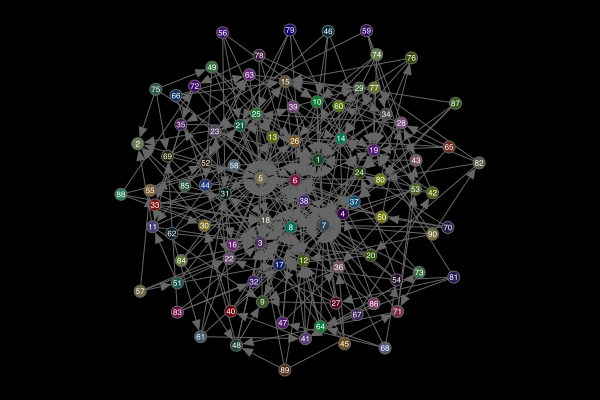

In [22]:
let
    @drawsvg begin
    background("black")
    sethue("grey40")
    fontsize(8)
    drawgraph(g, 
        layout=stress, 
        vertexlabels = 1:nv(g),
        vertexfillcolors = 
            [RGB(rand()/2, rand()/2, rand()/2) 
               for i in 1:nv(g)]
    )
    end 600 400
end